# Subject Identity via EEGNet (32-dim embedding)


# Identificacion de sujeto y ya?

In [ ]:
# ============================================================
# CELL I: Check available hardware
# ============================================================

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU             : None — running on CPU")
    print("\nNote: EEGNet with 7000 epochs is manageable on CPU,")
    print("      expect ~5-10 min per training run.")

PyTorch version : 2.5.1
CUDA available  : False
GPU             : None — running on CPU

Note: EEGNet with 7000 epochs is manageable on CPU,
      expect ~5-10 min per training run.


In [26]:
# ============================================================
# CELL II: Extract per-digit epochs from TASK segment
#
# Instead of one feature vector per subject (49 samples),
# we extract one 2-second epoch per digit utterance.
# Each subject has ~140 digits → ~7000 epochs total.
#
# Epoch structure:
#   Start : marker transition to digit code (1-10)
#   Length: 2 seconds = 256 samples at 128 Hz
#
# This gives us enough data to train a neural network.
# ============================================================

def extract_digit_epochs(edf_path, epoch_len_s=2.0, threshold_uv=150):
    """
    Extracts one EEG epoch per digit utterance from a BIOMEX EDF.

    Parameters
    ----------
    edf_path    : Path or str
    epoch_len_s : float — epoch length in seconds (default 2.0)

    Returns
    -------
    epochs      : np.ndarray, shape (n_digits, 14, n_samples)
    labels      : list of int — digit code (1-10) for each epoch
    """
    epoch_samples = int(epoch_len_s * SFREQ)   # 256 samples

    # ── Load and preprocess full signal ──────────────────────────
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

    # Extract MARKER before pick()
    marker_raw  = raw.get_data(picks=['MARKER'])[0]
    marker_data = np.round(marker_raw * 1e6).astype(int)

    # Preprocess EEG channels
    raw.pick(EEG_CHANNELS)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    raw.filter(l_freq=1.0, h_freq=50.0, fir_window='hamming', verbose=False)
    raw.notch_filter(freqs=50.0, verbose=False)

    data, _ = raw[:, :]
    thr_v    = threshold_uv * 1e-6
    data     = np.clip(data, -thr_v, thr_v)
    n_samples = data.shape[1]

    # ── Find digit marker transitions ────────────────────────────
    transitions = np.where(np.diff(marker_data) != 0)[0] + 1

    epochs, labels = [], []

    for idx in transitions:
        code = marker_data[idx]
        if 1 <= code <= 10:
            end = idx + epoch_samples
            if end <= n_samples:
                epochs.append(data[:, idx:end])
                labels.append(code)

    if len(epochs) == 0:
        return None, None

    return np.stack(epochs), labels   # (n_digits, 14, 256)


# ── Test on F001 ─────────────────────────────────────────────────
edf_test  = find_edf('F001', session='G10')
ep, lb    = extract_digit_epochs(edf_test)

print("=== Test extract_digit_epochs() — F001 G10 ===")
print(f"  Epochs shape : {ep.shape}  (n_digits × channels × samples)")
print(f"  Epoch length : {ep.shape[2] / SFREQ:.1f} s")
print(f"  Digit labels : {sorted(set(lb))}  (1=one ... 9=nine, 10=zero)")
print(f"  Label counts : {dict(zip(*np.unique(lb, return_counts=True)))}")

=== Test extract_digit_epochs() — F001 G10 ===
  Epochs shape : (100, 14, 256)  (n_digits × channels × samples)
  Epoch length : 2.0 s
  Digit labels : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (1=one ... 9=nine, 10=zero)
  Label counts : {1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10, 10: 10}


In [ ]:
# ============================================================
# CELL III: Build the full epoch dataset for all subjects
#
# For each subject: extract all digit epochs + assign subject ID
# Result: X of shape (n_total_epochs, 14, 256)
#         y of shape (n_total_epochs,) — subject index (0-50)
#
# We also store subject metadata aligned to epoch index
# so we can later analyse embeddings by sex/age.
# ============================================================

all_epochs   = []
all_subject  = []   # subject index (0-50) — used as classification target
all_sid      = []   # subject ID string — for reference
all_digit    = []   # digit label (1-10)

print(f"Extracting digit epochs for {len(metadata)} subjects...\n")
print(f"  {'Subject':8s}  {'Epochs':>6s}  {'Status'}")
print("  " + "-" * 28)

for subj_idx, row in metadata.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')

    if edf_path is None:
        print(f"  {sid:8s}  {'—':>6s}  EDF not found")
        continue

    try:
        epochs, labels = extract_digit_epochs(edf_path)

        if epochs is None:
            print(f"  {sid:8s}  {'—':>6s}  No epochs extracted")
            continue

        all_epochs.append(epochs)
        all_subject.extend([subj_idx] * len(labels))
        all_sid.extend([sid] * len(labels))
        all_digit.extend(labels)

        print(f"  {sid:8s}  {len(labels):>6d}  ✓")

    except Exception as e:
        print(f"  {sid:8s}  {'—':>6s}  ERROR: {e}")

# ── Assemble arrays ───────────────────────────────────────────────
X_epochs = np.concatenate(all_epochs, axis=0)   # (N, 14, 256)
y_subj   = np.array(all_subject)                # (N,) subject index
y_digit  = np.array(all_digit)                  # (N,) digit label

# Re-encode subject indices to be contiguous (0, 1, 2, ...)
y_subj = LabelEncoder().fit_transform(y_subj)
n_subjects = len(np.unique(y_subj))

print(f"\n=== Full epoch dataset ===")
print(f"  Total epochs   : {X_epochs.shape[0]}")
print(f"  Shape          : {X_epochs.shape}  (epochs × channels × samples)")
print(f"  Subjects       : {n_subjects}")
print(f"  Epochs/subject : ~{X_epochs.shape[0] // n_subjects}")
print(f"  Value range    : [{X_epochs.min()*1e6:.1f}, {X_epochs.max()*1e6:.1f}] µV")

Extracting digit epochs for 51 subjects...

  Subject   Epochs  Status
  ----------------------------
  F001         100  ✓
  F002         100  ✓
  F003         100  ✓
  F004         100  ✓
  F005         100  ✓
  F006         100  ✓
  F007         100  ✓
  F008         100  ✓
  F009         100  ✓
  F010         100  ✓
  F011         100  ✓
  F012         100  ✓
  F013         100  ✓
  F014         100  ✓
  F015         100  ✓
  F016         100  ✓
  F017         100  ✓
  F018         100  ✓
  F019         100  ✓
  F020         100  ✓
  F021         100  ✓
  F022         100  ✓
  F023         100  ✓
  F024         100  ✓
  F025         100  ✓
  M001         100  ✓
  M002         100  ✓
  M003         100  ✓
  M004         100  ✓
  M005         100  ✓
  M006         100  ✓
  M007         100  ✓
  M008         100  ✓
  M009         100  ✓
  M010         100  ✓
  M011         100  ✓
  M012         100  ✓
  M013         100  ✓
  M014         100  ✓
  M015         100  ✓
  M016         100

In [28]:
# ============================================================
# CELL IV: EEGNet architecture
#
# EEGNet (Lawhern et al. 2018) is specifically designed for
# EEG classification with small datasets. It has very few
# parameters (~1500) compared to generic CNNs, which prevents
# overfitting with limited data.
#
# Architecture:
#   Block 1: Temporal convolution → learns frequency filters
#   Block 2: Depthwise convolution → learns spatial filters
#             (one filter per channel — mimics beamforming)
#   Block 3: Separable convolution → learns temporal patterns
#   Embedding layer: 32-dim vector — the "neural fingerprint"
#   Output layer: 51 classes (one per subject)
#
# Input shape: (batch, 14, 256) — channels × time samples
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGNet(nn.Module):
    def __init__(self, n_classes=51, n_channels=14, n_samples=256,
                 F1=8, D=2, F2=16, embed_dim=32, dropout=0.5):
        """
        Parameters
        ----------
        n_classes  : int — number of subjects to identify
        n_channels : int — EEG channels (14)
        n_samples  : int — time samples per epoch (256)
        F1         : int — number of temporal filters
        D          : int — depth multiplier for spatial filters
        F2         : int — number of separable filters (= F1 * D)
        embed_dim  : int — embedding vector size
        dropout    : float — dropout rate
        """
        super(EEGNet, self).__init__()

        # ── Block 1: Temporal convolution ────────────────────────
        # Learns frequency-specific filters across time
        # kernel_size = 64 = 0.5s at 128Hz (captures 2Hz+ patterns)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32),
                      bias=False),
            nn.BatchNorm2d(F1)
        )

        # ── Block 2: Depthwise spatial convolution ────────────────
        # One filter per channel — learns which channels matter
        # groups=F1 enforces depthwise (one filter per input map)
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )

        # ── Block 3: Separable convolution ───────────────────────
        # Learns temporal patterns in the spatially-filtered signal
        self.block3 = nn.Sequential(
            nn.Conv2d(F2, F2, kernel_size=(1, 16), padding=(0, 8),
                      groups=F2, bias=False),
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        # ── Compute flattened size after convolutions ─────────────
        self._flat_size = self._get_flat_size(n_channels, n_samples, F1, D, F2)

        # ── Embedding layer — the neural fingerprint ──────────────
        self.embedding = nn.Linear(self._flat_size, embed_dim)

        # ── Classification head ───────────────────────────────────
        self.classifier = nn.Linear(embed_dim, n_classes)

    def _get_flat_size(self, n_channels, n_samples, F1, D, F2):
        """Pass a dummy tensor to compute the flattened size."""
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.block1(x)
            x = self.block2(x)
            x = self.block3(x)
            return x.view(1, -1).shape[1]

    def forward(self, x, return_embedding=False):
        """
        Parameters
        ----------
        x                : tensor, shape (batch, 14, 256)
        return_embedding : if True, return 32-dim embedding instead
                           of class logits — used at inference time
                           to extract the neural fingerprint
        """
        # Add channel dimension: (batch, 14, 256) → (batch, 1, 14, 256)
        x = x.unsqueeze(1)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)          # flatten

        embed = F.elu(self.embedding(x))    # (batch, 32)

        if return_embedding:
            return embed

        return self.classifier(embed)       # (batch, n_classes)


# ── Sanity check ─────────────────────────────────────────────────
model = EEGNet(n_classes=51, n_channels=14, n_samples=256,
               embed_dim=32, dropout=0.5)

dummy = torch.zeros(8, 14, 256)   # batch of 8 epochs
out   = model(dummy)
emb   = model(dummy, return_embedding=True)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== EEGNet architecture ===\n")
print(model)
print(f"\n  Input shape      : {list(dummy.shape)}")
print(f"  Output shape     : {list(out.shape)}  (batch × n_subjects)")
print(f"  Embedding shape  : {list(emb.shape)}   (batch × embed_dim)")
print(f"  Trainable params : {n_params:,}")

=== EEGNet architecture ===

EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(14, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (embedding): Line

In [29]:
# ============================================================
# CELL V: Training pipeline for EEGNet
#
# Strategy:
#   - 80% train / 20% test split, stratified by subject
#     (so every subject has epochs in both sets)
#   - Normalize each epoch to zero mean and unit variance
#     (per epoch, not per dataset — more robust to artifacts)
#   - Adam optimizer, lr=1e-3, weight decay for regularization
#   - 50 epochs of training — enough for CPU in ~10 min
#   - Save best model based on validation accuracy
# ============================================================

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import time

# ── 1. Normalize epochs (per epoch, zero mean + unit std) ────────
X_norm = X_epochs.copy().astype(np.float32)
X_norm = (X_norm - X_norm.mean(axis=2, keepdims=True)) / \
         (X_norm.std(axis=2, keepdims=True) + 1e-8)

# ── 2. Train/test split stratified by subject ─────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_subj,
    test_size=0.20,
    stratify=y_subj,
    random_state=42
)

print(f"  Train: {X_train.shape[0]} epochs")
print(f"  Test : {X_test.shape[0]} epochs")

# ── 3. PyTorch tensors and DataLoaders ────────────────────────────
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                          batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te, y_te),
                          batch_size=64, shuffle=False)

# ── 4. Model, optimizer, loss ─────────────────────────────────────
model     = EEGNet(n_classes=51, n_channels=14, n_samples=256,
                   embed_dim=32, dropout=0.5)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                            step_size=20, gamma=0.5)

# ── 5. Training loop ──────────────────────────────────────────────
N_EPOCHS   = 50
best_acc   = 0.0
best_state = None
history    = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print(f"\n  Training EEGNet for {N_EPOCHS} epochs on CPU...")
print(f"  {'Epoch':>6s}  {'Train loss':>11s}  "
      f"{'Train acc':>10s}  {'Test acc':>9s}  {'Time':>6s}")
print("  " + "-" * 52)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    # ── Train ────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total   += len(yb)

    scheduler.step()

    # ── Evaluate ─────────────────────────────────────────────
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            test_correct += (logits.argmax(1) == yb).sum().item()
            test_total   += len(yb)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    test_acc       = test_correct  / test_total
    elapsed        = time.time() - t0

    history['train_loss'].append(train_loss_avg)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if test_acc > best_acc:
        best_acc   = test_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:>6d}  {train_loss_avg:>11.4f}  "
              f"{train_acc:>9.3f}  {test_acc:>9.3f}  {elapsed:>5.1f}s")

print(f"\n  Best test accuracy: {best_acc:.3f}  "
      f"({best_acc*100:.1f}%)  —  chance = {1/51*100:.1f}%")

# Load best model weights
model.load_state_dict(best_state)

  Train: 4080 epochs
  Test : 1020 epochs

  Training EEGNet for 50 epochs on CPU...
   Epoch   Train loss   Train acc   Test acc    Time
  ----------------------------------------------------
       1       3.8701      0.043      0.086    4.3s
       5       3.0494      0.252      0.316    4.1s
      10       2.3383      0.374      0.475    4.3s
      15       1.9438      0.464      0.582    4.6s
      20       1.7134      0.508      0.643    4.1s
      25       1.6050      0.549      0.658    3.7s
      30       1.5524      0.550      0.677    4.1s
      35       1.4813      0.569      0.686    4.6s
      40       1.4522      0.576      0.684    4.0s
      45       1.4273      0.580      0.695    3.7s
      50       1.4044      0.596      0.710    4.1s

  Best test accuracy: 0.710  (71.0%)  —  chance = 2.0%


<All keys matched successfully>

In [30]:
# ============================================================
# CELL VI: Continue training 50 more epochs
# The model is still improving at epoch 50 — let's see
# if it plateaus or keeps climbing with 50 more epochs.
# ============================================================

print(f"  Continuing training from epoch {N_EPOCHS}...\n")
print(f"  {'Epoch':>6s}  {'Train loss':>11s}  "
      f"{'Train acc':>10s}  {'Test acc':>9s}  {'Time':>6s}")
print("  " + "-" * 52)

for epoch in range(N_EPOCHS + 1, N_EPOCHS + 51):
    t0 = time.time()

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total   += len(yb)

    scheduler.step()

    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            test_correct += (logits.argmax(1) == yb).sum().item()
            test_total   += len(yb)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    test_acc       = test_correct  / test_total
    elapsed        = time.time() - t0

    history['train_loss'].append(train_loss_avg)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if test_acc > best_acc:
        best_acc   = test_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"  {epoch:>6d}  {train_loss_avg:>11.4f}  "
              f"{train_acc:>9.3f}  {test_acc:>9.3f}  {elapsed:>5.1f}s")

model.load_state_dict(best_state)
print(f"\n  Best test accuracy so far: {best_acc:.3f}  ({best_acc*100:.1f}%)")

  Continuing training from epoch 50...

   Epoch   Train loss   Train acc   Test acc    Time
  ----------------------------------------------------
      60       1.3589      0.602      0.715    3.3s
      70       1.3683      0.598      0.718    3.3s
      80       1.3499      0.599      0.725    3.8s
      90       1.3056      0.618      0.728    3.5s
     100       1.3338      0.599      0.727    3.4s

  Best test accuracy so far: 0.731  (73.1%)


Embeddings shape: (1020, 32)
Running t-SNE (this takes ~1 min)...


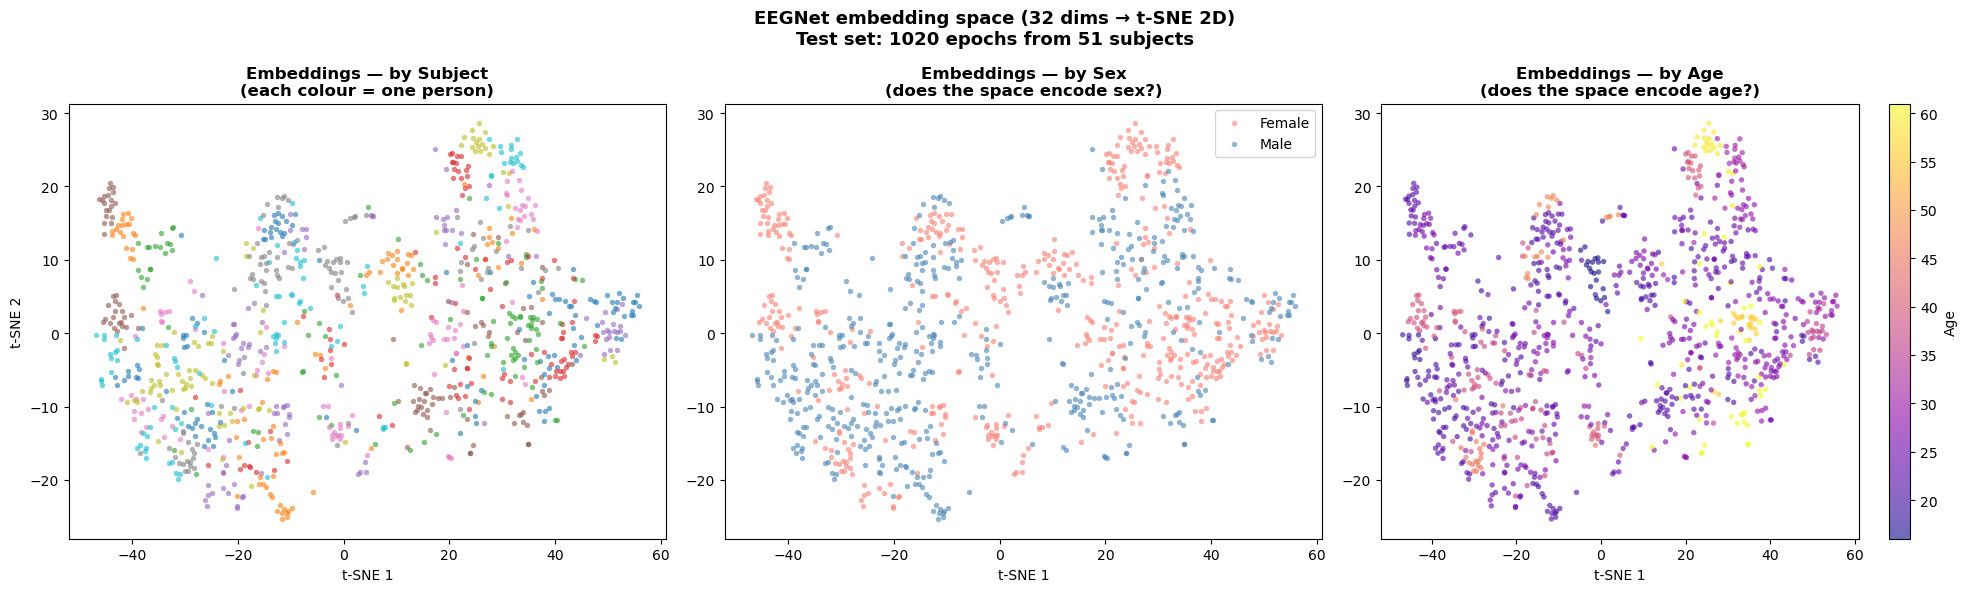

In [31]:
# ============================================================
# CELL VII: Visualise the 32-dim embeddings with t-SNE
#
# t-SNE reduces 32 dimensions → 2 for visualisation.
# If EEGNet has learned a good neural fingerprint,
# epochs from the same subject should cluster together.
#
# We colour by: (1) subject, (2) sex, (3) age
# This shows whether the embedding space captures
# demographic structure beyond just identity.
# ============================================================

from sklearn.manifold import TSNE

# ── Extract embeddings for all test epochs ────────────────────────
model.eval()
embeddings = []
true_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        emb = model(xb, return_embedding=True)   # (batch, 32)
        embeddings.append(emb.numpy())
        true_labels.extend(yb.numpy())

embeddings  = np.concatenate(embeddings, axis=0)   # (1020, 32)
true_labels = np.array(true_labels)                # (1020,)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Running t-SNE (this takes ~1 min)...")

# ── t-SNE ─────────────────────────────────────────────────────────
tsne  = TSNE(n_components=2, perplexity=30, random_state=42,
             n_iter=1000, verbose=0)
emb2d = tsne.fit_transform(embeddings)             # (1020, 2)

# ── Build metadata aligned to test epochs ────────────────────────
# Map subject index back to subject ID and metadata
le_subj   = LabelEncoder().fit(y_subj)
sid_array = np.array(all_sid)

# Rebuild test subject IDs using the same split
_, _, sid_train, sid_test = train_test_split(
    X_norm, np.array(all_sid),
    test_size=0.20, stratify=y_subj, random_state=42)

meta_test = pd.DataFrame({'subject_id': sid_test})
meta_test = meta_test.merge(metadata, on='subject_id')

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: coloured by subject (each subject = one colour)
ax = axes[0]
for subj_idx in np.unique(true_labels):
    mask = true_labels == subj_idx
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1],
               s=15, alpha=0.6, linewidths=0)
ax.set_title("Embeddings — by Subject\n"
             "(each colour = one person)", fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# Panel 2: coloured by sex
ax = axes[1]
sex_colors = {'Female': 'salmon', 'Male': 'steelblue'}
for label in ['Female', 'Male']:
    mask = meta_test['sex'].values == label
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1],
               c=sex_colors[label], s=15, alpha=0.6,
               linewidths=0, label=label)
ax.set_title("Embeddings — by Sex\n"
             "(does the space encode sex?)", fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.legend()

# Panel 3: coloured by age
ax = axes[2]
scatter = ax.scatter(emb2d[:, 0], emb2d[:, 1],
                     c=meta_test['age'].values,
                     cmap='plasma', s=15, alpha=0.6, linewidths=0)
plt.colorbar(scatter, ax=ax, label='Age')
ax.set_title("Embeddings — by Age\n"
             "(does the space encode age?)", fontweight='bold')
ax.set_xlabel("t-SNE 1")

plt.suptitle("EEGNet embedding space (32 dims → t-SNE 2D)\n"
             "Test set: 1020 epochs from 51 subjects",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Qué queda por hacer?:

1- La primera es identificación con sesión G04 — ahora mismo todo lo hemos hecho con G10 (series de 10 dígitos). G04 tiene series más cortas. Probar cross-session (entrenar en G10, testear en G04) demostraría que la huella neurológica es estable entre sesiones. Eso es muy relevante para el argumento de que el EEG captura algo genuinamente individual.


2- La segunda es guardar los embeddings a disco — los 32 valores por sujeto que ha aprendido EEGNet son el input directo de Fase 3. Si no los guardas ahora tendrás que reentrenar la red más adelante.

In [32]:
# ============================================================
# CELL a: Cross-session evaluation
#
# So far we trained and tested on G10 (10-digit series).
# BIOMEX also has G04 (4-digit series) for every subject.
#
# Goal: train EEGNet on G10, test on G04.
# If the neural fingerprint is genuine, the model should
# identify subjects even in a completely unseen session.
#
# This is a much harder test than random train/test split —
# the model has never seen any G04 data during training.
# ============================================================

print("Extracting G04 epochs for all subjects...")
print(f"\n  {'Subject':8s}  {'Epochs':>6s}  {'Status'}")
print("  " + "-" * 28)

all_epochs_g04  = []
all_subject_g04 = []
all_sid_g04     = []

for subj_idx, row in metadata.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G04')

    if edf_path is None:
        print(f"  {sid:8s}  {'—':>6s}  EDF not found")
        continue

    try:
        epochs, labels = extract_digit_epochs(edf_path)

        if epochs is None:
            print(f"  {sid:8s}  {'—':>6s}  No epochs extracted")
            continue

        all_epochs_g04.append(epochs)
        all_subject_g04.extend([subj_idx] * len(labels))
        all_sid_g04.extend([sid] * len(labels))

        print(f"  {sid:8s}  {len(labels):>6d}  ✓")

    except Exception as e:
        print(f"  {sid:8s}  {'—':>6s}  ERROR: {e}")

# ── Assemble G04 dataset ──────────────────────────────────────────
X_g04   = np.concatenate(all_epochs_g04, axis=0)
y_g04   = LabelEncoder().fit_transform(np.array(all_subject_g04))
sid_g04 = np.array(all_sid_g04)

print(f"\n=== G04 dataset ===")
print(f"  Total epochs   : {X_g04.shape[0]}")
print(f"  Shape          : {X_g04.shape}")
print(f"  Subjects       : {len(np.unique(y_g04))}")
print(f"  Epochs/subject : ~{X_g04.shape[0] // len(np.unique(y_g04))}")

Extracting G04 epochs for all subjects...

  Subject   Epochs  Status
  ----------------------------
  F001          40  ✓
  F002          40  ✓
  F003          40  ✓
  F004          40  ✓
  F005          40  ✓
  F006          40  ✓
  F007          40  ✓
  F008          40  ✓
  F009          40  ✓
  F010          40  ✓
  F011          40  ✓
  F012          40  ✓
  F013          40  ✓
  F014          40  ✓
  F015          40  ✓
  F016          40  ✓
  F017          40  ✓
  F018          40  ✓
  F019          40  ✓
  F020          40  ✓
  F021          40  ✓
  F022          40  ✓
  F023          40  ✓
  F024          40  ✓
  F025          40  ✓
  M001          40  ✓
  M002          40  ✓
  M003          40  ✓
  M004          40  ✓
  M005          40  ✓
  M006          40  ✓
  M007          40  ✓
  M008          40  ✓
  M009          40  ✓
  M010          40  ✓
  M011          40  ✓
  M012          40  ✓
  M013          40  ✓
  M014          40  ✓
  M015          40  ✓
  M016          40 

In [33]:
# ============================================================
# CELL b: Cross-session inference
#
# We use the EEGNet trained on G10 (no retraining)
# and evaluate it directly on G04 epochs.
#
# This tests whether the neural fingerprint generalises
# across sessions — a much stricter test than same-session
# train/test split.
#
# We also compare three scenarios:
#   1. Same-session (G10 train → G10 test) — already done: 73.1%
#   2. Cross-session (G10 train → G04 test) — new
#   3. Chance level: 1/51 = 2.0%
# ============================================================

# ── Normalize G04 epochs (same as G10) ───────────────────────────
X_g04_norm = X_g04.copy().astype(np.float32)
X_g04_norm = (X_g04_norm - X_g04_norm.mean(axis=2, keepdims=True)) / \
             (X_g04_norm.std(axis=2, keepdims=True) + 1e-8)

# ── The subject indices in G04 must match G10 encoding ───────────
# y_subj was encoded with LabelEncoder on G10 subject list.
# We need to re-encode G04 using the same mapping.
le_g10 = LabelEncoder().fit(y_subj)

# Map G04 subject indices through G10 label encoder
# (both use metadata.iterrows() order so indices match)
y_g04_aligned = y_g04   # same iterrows order → same encoding

# ── Evaluate on G04 ──────────────────────────────────────────────
X_g04_tensor = torch.tensor(X_g04_norm, dtype=torch.float32)
y_g04_tensor = torch.tensor(y_g04_aligned, dtype=torch.long)

g04_loader = DataLoader(TensorDataset(X_g04_tensor, y_g04_tensor),
                        batch_size=64, shuffle=False)

model.eval()
correct, total = 0, 0
per_subject_correct = {}
per_subject_total   = {}

with torch.no_grad():
    for xb, yb in g04_loader:
        logits = model(xb)
        preds  = logits.argmax(1)

        for pred, true in zip(preds.numpy(), yb.numpy()):
            per_subject_total[true]   = per_subject_total.get(true, 0) + 1
            per_subject_correct[true] = per_subject_correct.get(true, 0) + (pred == true)

        correct += (preds == yb).sum().item()
        total   += len(yb)

cross_acc = correct / total

print("=== Cross-session evaluation: G10 train → G04 test ===\n")
print(f"  Same-session  accuracy (G10→G10) : 73.1%")
print(f"  Cross-session accuracy (G10→G04) : {cross_acc*100:.1f}%")
print(f"  Chance level                     :  2.0%\n")

# ── Per-subject breakdown ─────────────────────────────────────────
print(f"  Per-subject accuracy:")
print(f"  {'Subject':8s}  {'Correct':>7s}  {'Total':>5s}  {'Acc':>6s}")
print("  " + "-" * 32)

accs = []
for subj_idx in sorted(per_subject_total.keys()):
    sid      = metadata.iloc[subj_idx]['subject_id']
    n_correct = per_subject_correct.get(subj_idx, 0)
    n_total   = per_subject_total[subj_idx]
    acc       = n_correct / n_total
    accs.append(acc)
    bar = "█" * int(acc * 10)
    print(f"  {sid:8s}  {n_correct:>7d}  {n_total:>5d}  "
          f"{acc:>5.1%}  {bar}")

print(f"\n  Mean per-subject accuracy : {np.mean(accs)*100:.1f}%")
print(f"  Subjects with >50% acc    : {sum(a > 0.5 for a in accs)}/51")
print(f"  Subjects with >75% acc    : {sum(a > 0.75 for a in accs)}/51")
print(f"  Subjects with 100% acc    : {sum(a == 1.0 for a in accs)}/51")

=== Cross-session evaluation: G10 train → G04 test ===

  Same-session  accuracy (G10→G10) : 73.1%
  Cross-session accuracy (G10→G04) : 58.5%
  Chance level                     :  2.0%

  Per-subject accuracy:
  Subject   Correct  Total     Acc
  --------------------------------
  F001           36     40  90.0%  █████████
  F002           33     40  82.5%  ████████
  F003            9     40  22.5%  ██
  F004           17     40  42.5%  ████
  F005           12     40  30.0%  ███
  F006           31     40  77.5%  ███████
  F007           32     40  80.0%  ████████
  F008           37     40  92.5%  █████████
  F009           29     40  72.5%  ███████
  F010           11     40  27.5%  ██
  F011           36     40  90.0%  █████████
  F012           22     40  55.0%  █████
  F013           29     40  72.5%  ███████
  F014           31     40  77.5%  ███████
  F015           28     40  70.0%  ███████
  F016           31     40  77.5%  ███████
  F017           22     40  55.0%  █████
  

In [34]:
# ============================================================
# CELL c: Save embeddings and model to disk
#
# We save three things:
#   1. EEGNet model weights — to reload without retraining
#   2. G10 embeddings — 32-dim neural fingerprint per epoch
#   3. Subject-level embeddings — mean across epochs per subject
#      (this is the single vector that represents each person
#       and will be used as input to Phase 3)
# ============================================================

import pickle
from pathlib import Path

SAVE_DIR = PROJECT_ROOT / "embeddings"
SAVE_DIR.mkdir(exist_ok=True)

# ── 1. Save model weights ─────────────────────────────────────────
model_path = SAVE_DIR / "eegnet_g10.pt"
torch.save(best_state, model_path)
print(f"  Model saved → {model_path}")

# ── 2. Extract G10 embeddings for ALL epochs ──────────────────────
X_g10_norm = X_norm.copy()
X_g10_tensor = torch.tensor(X_g10_norm, dtype=torch.float32)
g10_loader_all = DataLoader(TensorDataset(X_g10_tensor),
                            batch_size=64, shuffle=False)

model.eval()
all_embeddings_g10 = []

with torch.no_grad():
    for (xb,) in g10_loader_all:
        emb = model(xb, return_embedding=True)
        all_embeddings_g10.append(emb.numpy())

all_embeddings_g10 = np.concatenate(all_embeddings_g10, axis=0)  # (5100, 32)

# ── 3. Compute subject-level mean embedding ───────────────────────
# Average all epochs from the same subject → one 32-dim vector
# This is the "neural fingerprint" of each person
subject_embeddings = {}

for subj_idx in np.unique(y_subj):
    mask      = y_subj == subj_idx
    sid       = metadata.iloc[subj_idx]['subject_id']
    mean_emb  = all_embeddings_g10[mask].mean(axis=0)   # (32,)
    subject_embeddings[sid] = mean_emb

# ── 4. Build a clean DataFrame: one row per subject ───────────────
embed_cols = [f"emb_{i:02d}" for i in range(32)]

rows = []
for sid, emb in subject_embeddings.items():
    row = {'subject_id': sid}
    row.update({col: val for col, val in zip(embed_cols, emb)})
    rows.append(row)

embeddings_df = pd.DataFrame(rows)
embeddings_df = embeddings_df.merge(metadata, on='subject_id')

# ── 5. Save to disk ───────────────────────────────────────────────
embeddings_path = SAVE_DIR / "subject_embeddings.csv"
epochs_path     = SAVE_DIR / "epoch_embeddings_g10.npy"
labels_path     = SAVE_DIR / "epoch_labels_g10.npy"

embeddings_df.to_csv(embeddings_path, index=False)
np.save(epochs_path, all_embeddings_g10)
np.save(labels_path, y_subj)

print(f"  Subject embeddings saved → {embeddings_path}")
print(f"  Epoch embeddings saved   → {epochs_path}")
print(f"  Epoch labels saved       → {labels_path}")

print(f"\n=== Saved files summary ===")
print(f"  eegnet_g10.pt            : EEGNet weights")
print(f"  subject_embeddings.csv   : {len(embeddings_df)} subjects × "
      f"32 embedding dims + metadata")
print(f"  epoch_embeddings_g10.npy : {all_embeddings_g10.shape} "
      f"(all epochs × 32 dims)")
print(f"  epoch_labels_g10.npy     : {y_subj.shape} (subject index per epoch)")

print(f"\n=== Preview: subject embeddings ===")
print(embeddings_df[['subject_id', 'sex', 'age'] + embed_cols[:5]].head(10))

  Model saved → C:\Users\Laura\OneDrive\Escritorio\TFM_part1\embeddings\eegnet_g10.pt
  Subject embeddings saved → C:\Users\Laura\OneDrive\Escritorio\TFM_part1\embeddings\subject_embeddings.csv
  Epoch embeddings saved   → C:\Users\Laura\OneDrive\Escritorio\TFM_part1\embeddings\epoch_embeddings_g10.npy
  Epoch labels saved       → C:\Users\Laura\OneDrive\Escritorio\TFM_part1\embeddings\epoch_labels_g10.npy

=== Saved files summary ===
  eegnet_g10.pt            : EEGNet weights
  subject_embeddings.csv   : 51 subjects × 32 embedding dims + metadata
  epoch_embeddings_g10.npy : (5100, 32) (all epochs × 32 dims)
  epoch_labels_g10.npy     : (5100,) (subject index per epoch)

=== Preview: subject embeddings ===
  subject_id     sex  age    emb_00    emb_01    emb_02    emb_03    emb_04
0       F001  Female   22 -0.555439 -0.688959  6.821943 -0.522149  4.158260
1       F002  Female   26  1.508801  1.745111  6.839621 -0.352441  8.854443
2       F003  Female   27  2.271516 -0.266183  0.12765